---

# **<font color="#6767bf"> Modelación Climática Tropical</font>**
## **<font color="#8282d6"> Atlantic Multidecadal Variability </font>**
### **<font color="#a6a6f1"> Índices, mapas y anomalías GPCP</font>**


---

In [1]:
pip install xarray

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install cftime

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install netCDF4 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from cartopy.util import add_cyclic_point
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.stats import t

In [7]:
def lineplot_setup(xmin,xmax,xlab,ylab,ymin=None,ymax=None,title=None,legend=False):
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(xlab,fontsize=14)
    plt.ylabel(ylab,fontsize=14)
    plt.title(title,fontsize=14)
    if legend:
        plt.legend(fancybox=True,shadow=True,fontsize=9)

In [8]:
def mapa_MC(data, levels, ccmap, titulo, extend='both', cbarlabel='pr  [mm día$^{-1}$]', 
            limite_NS=75, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    lons, lats = data.lon, data.lat
    data, lon = add_cyclic_point(data, coord=lons)
    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    cs = ax.contourf(lon, lats, data, levels=levels, cmap=ccmap, extend=extend, transform=ccrs.PlateCarree())

    if lon_min is not None and lon_max is not None and lat_min is not None and lat_max is not None:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([0, 359.1, -limite_NS, limite_NS], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='k', linewidth=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    plt.title(titulo, fontsize=19)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.046, pad=0.06)
    cbar.ax.set_xlabel(cbarlabel)

In [9]:
# Cargamos el archivo del índice AMV de la NOAA ERSSTv5
file_path = 'AMV_NOAA_df.csv'
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])  

In [10]:
# Imprimimos los valores positivos
#positivos = amv_JJAS[amv_JJAS['AMV_NOAA'] > 0]
#positivos

In [11]:
df['rolled']=df.AMV_NOAA.rolling(window=120, min_periods=60).mean()

In [12]:
# se filtran los meses de JJAS con dt month que extrae el mes y con isin se especifican las filas
amv_JJAS = df[df['Date'].dt.month.isin([6, 7, 8, 9])]
print(amv_JJAS)

           Date  AMV_NOAA    rolled
5    1854-06-15     -0.18       NaN
6    1854-07-15     -0.07       NaN
7    1854-08-15     -0.20       NaN
8    1854-09-15     -0.04       NaN
17   1855-06-15     -0.06       NaN
...         ...       ...       ...
2024 2022-09-15      0.98  0.592750
2033 2023-06-15      1.27  0.624000
2034 2023-07-15      1.44  0.631583
2035 2023-08-15      1.36  0.638750
2036 2023-09-15      1.42  0.645500

[680 rows x 3 columns]


In [13]:
#plt.plot(df.AMV_NOAA,label='Original')
#plt.plot(df.rolled,label='Suavizado')
#plt.legend()

In [14]:
# Imprimimos los valores negativos
negativos = amv_JJAS[amv_JJAS['AMV_NOAA'] < 0]
negativos

,Date,AMV_NOAA,rolled
5,1854-06-15,-0.18,NaN
6,1854-07-15,-0.07,NaN
7,1854-08-15,-0.20,NaN
8,1854-09-15,-0.04,NaN
17,1855-06-15,-0.06,NaN
...,...,...,...
1687,1994-08-15,-0.22,-0.046417
1688,1994-09-15,-0.18,-0.047083
1709,1996-06-15,-0.03,0.023917
1710,1996-07-15,-0.08,0.024833


In [15]:
# cargamos los archivos, tanto el csv como el .nc con la variable
# Archivo de precipitación GPCP
filename='/home/jovyan/ModClim/datos_actualizados/precip.mon.mean.nc'
ds=xr.open_dataset(filename)
pr=ds['precip']
pr['units']='mm day-1'

In [16]:
lons=pr.lon
lats=pr.lat
#pr=pr.loc[dict(lat=lats[lats>0])]
#pr=pr.loc[dict(lon=lons[lons>180])]

In [17]:
df_csv=df

In [18]:
# Tenemos que obtener el promedio de los años con AMV 
pr_jjas=pr.sel(time=pr['time'].dt.month.isin([6, 7, 8, 9]))
print(pr_jjas)

<xarray.DataArray 'precip' (time: 184, lat: 72, lon: 144)> Size: 8MB
[1907712 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1kB 1979-06-01 1979-07-01 ... 2024-09-01
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    units    <U8 32B 'mm day-1'
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]


In [19]:
# Seleccionamos el área especifica
time_yrsprep=pr_jjas.sel(time=slice('1979', '2023'))
pr_jjas_centromex = time_yrsprep.sel(lat=slice(13.75, 23.75),lon=slice(253.75, 273.5))
#pr_jjas_centromex=pr_jjas_centromex.mean()
pr_jjas_prom_centromex = pr_jjas_centromex.mean(dim=["lat", "lon"]) #skipna=True

pr_jjas_prom_centromex_anual=pr_jjas_prom_centromex.groupby('time.year').mean('time')

pr_jjas_prom_centromex_anual

<xarray.DataArray 'precip' (year: 45)> Size: 180B
array([6.7181826, 6.8080893, 7.2903404, 5.521323 , 7.369048 , 8.433081 ,
       6.4055357, 5.649135 , 6.6072936, 8.356257 , 7.102383 , 6.5933084,
       5.853492 , 6.9908905, 7.7939687, 5.2165475, 7.728795 , 6.9522467,
       6.124093 , 7.452005 , 7.8561244, 6.8498893, 6.021634 , 6.780509 ,
       7.1034193, 6.3585653, 6.7730055, 6.3876925, 6.5596404, 8.039681 ,
       5.5425253, 8.644418 , 7.3501105, 6.5956154, 7.4494057, 6.800964 ,
       5.3877473, 6.2993274, 7.0593243, 5.801897 , 5.4035482, 6.5293   ,
       6.742091 , 6.755791 , 4.9086556], dtype=float32)
Coordinates:
  * year     (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023
    units    <U8 32B 'mm day-1'
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

In [20]:
years_amv = [1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
df_filtrado = amv_JJAS[amv_JJAS['Date'].dt.year.isin(years_amv)]


df_filtrado['year'] = df_filtrado['Date'].dt.year
promedios_amv = df_filtrado.groupby('year')['rolled'].mean()
print(promedios_amv)

year
1979   -0.212938
1980   -0.192188
1981   -0.161354
1982   -0.129979
1983   -0.112063
1984   -0.081875
1985   -0.072854
1986   -0.066812
1987   -0.048917
1988   -0.020458
1989   -0.010500
1990   -0.014063
1991   -0.012167
1992   -0.019396
1993   -0.032771
1994   -0.046271
1995   -0.006750
1996    0.027021
1997    0.035417
1998    0.054896
1999    0.087729
2000    0.105687
2001    0.122021
2002    0.165187
2003    0.210521
2004    0.272167
2005    0.305729
2006    0.347208
2007    0.386250
2008    0.394813
2009    0.384542
2010    0.418104
2011    0.444854
2012    0.455771
2013    0.479417
2014    0.473896
2015    0.465688
2016    0.476500
2017    0.499437
2018    0.512229
2019    0.533187
2020    0.548063
2021    0.563438
2022    0.591313
2023    0.634958
Name: rolled, dtype: float64


/tmp/ipykernel_806/1498385394.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['year'] = df_filtrado['Date'].dt.year


In [21]:
print(len(promedios_amv), len(pr_jjas_prom_centromex_anual))  # iguales

45 45


In [22]:
x = promedios_amv.values.astype(float)
y = pr_jjas_prom_centromex_anual.values.astype(float)

In [23]:
years = np.arange(1979, 2024)

In [24]:
X2=x
#np.save('promediosAMV_GPCP_modelo.npy',X2)
y2=y
#np.save('promediosprecip_GPCP_modelo.npy',y2)

In [25]:
print(len(X2), len(y2))  # iguales

45 45


In [26]:
# 2. Coeficientes
m2 = np.sum((X2 - X2.mean()) * (y2 - y2.mean())) / np.sum((X2 - X2.mean())**2)
b2 = y2.mean() - m2 * X2.mean()
#predicciones2= b2 + m2 * years
predicciones2 = m2 * X2 + b2      #predicciones 
#np.save('predicciones_GPCP_modelo.npy',predicciones2)
m2

np.float64(-0.6275320412174304)

In [27]:
residual = y2 - predicciones2
#np.save('residual_GPCP_AMV.npy',residual)
# Calcular pendiente 
m4 = np.sum((years - np.mean(years)) * (residual - np.mean(residual))) / np.sum((years - np.mean(years))**2)
b4 =  np.mean(residual) - m4 * np.mean(years)
predicciones= b4 + m4 * years
m4_siglo=m4*100
m4_siglo
#np.save('predicciones_GPCP_AMV.npy',predicciones)
#np.save('pendiente_GPCP_sinAMV.npy',m4_siglo)

np.float64(-0.1831201018385571)

In [28]:
from statistics import correlation

r=correlation(X2, y2)

round(r,2)
#np.save('correlacion_GPCP.npy',r)

-0.19

In [29]:
from scipy import stats

correlacion_spearman, p_value = stats.spearmanr(X2, y2)

print(f"correlación de Spearman GPCP: {correlacion_spearman}")
print(f"p-val: {p_value}")

correlación de Spearman GPCP: -0.18550724637681157
p-val: 0.2224552556740683


In [30]:
from scipy.stats import pearsonr

r, p_value = pearsonr(X2, y2)
print("Coeficiente de correlación de Pearson:", r)
print("Valor p:", p_value)

Coeficiente de correlación de Pearson: -0.18671477044130347
Valor p: 0.21940594785676276


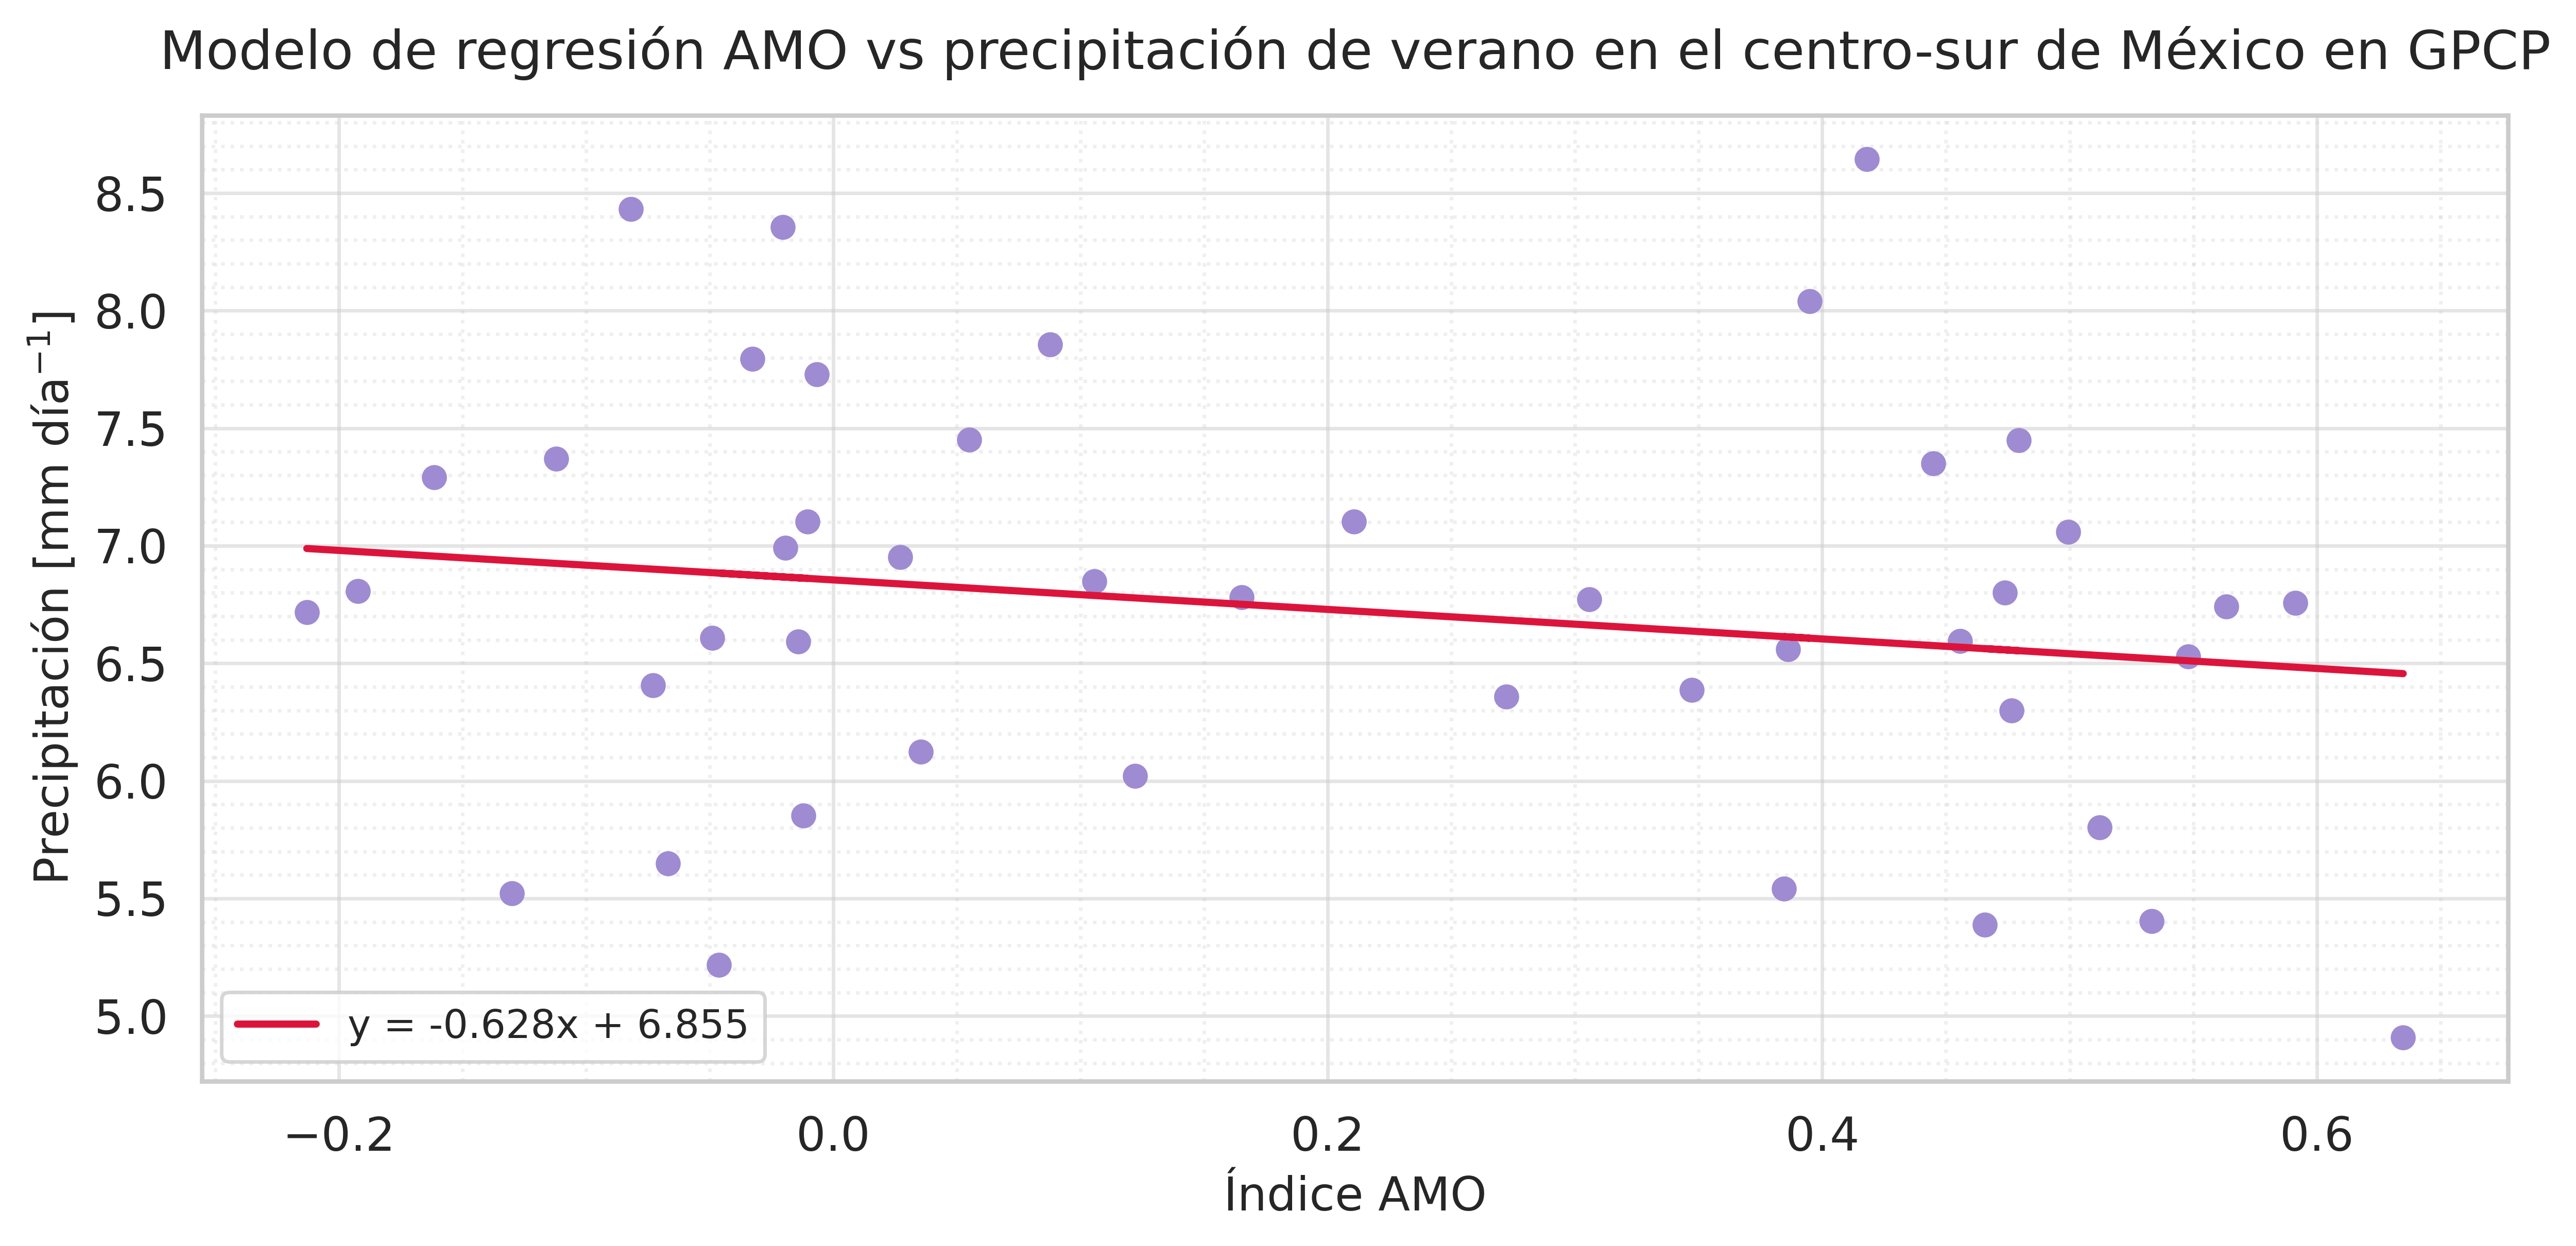

In [31]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=500)
plt.scatter(x, y, color='#9f8bd1')
plt.plot(X2, predicciones2, color='crimson', linewidth=2, label=f'y = {m2:.3f}x + {b2:.3f}')
# Etiquetas
plt.xlabel('Índice AMO', fontsize=13)
plt.ylabel('Precipitación [mm día$^{-1}$]', fontsize=13)
plt.title('Modelo de regresión AMO vs precipitación de verano en el centro-sur de México en GPCP',fontsize=15 ,pad=13, x=0.5)
plt.grid(True, which='major', linestyle='-', alpha=0.5)  
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.3)  
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.grid(True)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [32]:
res = stats.linregress(X2, y2)
#np.save('predicciones_mswep.npy', predicciones2)
print(res)

LinregressResult(slope=np.float64(-0.6275320412174306), intercept=np.float64(6.854683219590517), rvalue=np.float64(-0.18671477044130336), pvalue=np.float64(0.21940594785676323), stderr=np.float64(0.5035210358174202), intercept_stderr=np.float64(0.16199979365907502))


In [33]:
df = len(X2) - 2
t_obs = res.slope / res.stderr
t_crit = t.ppf(1 - 0.05/2, df)

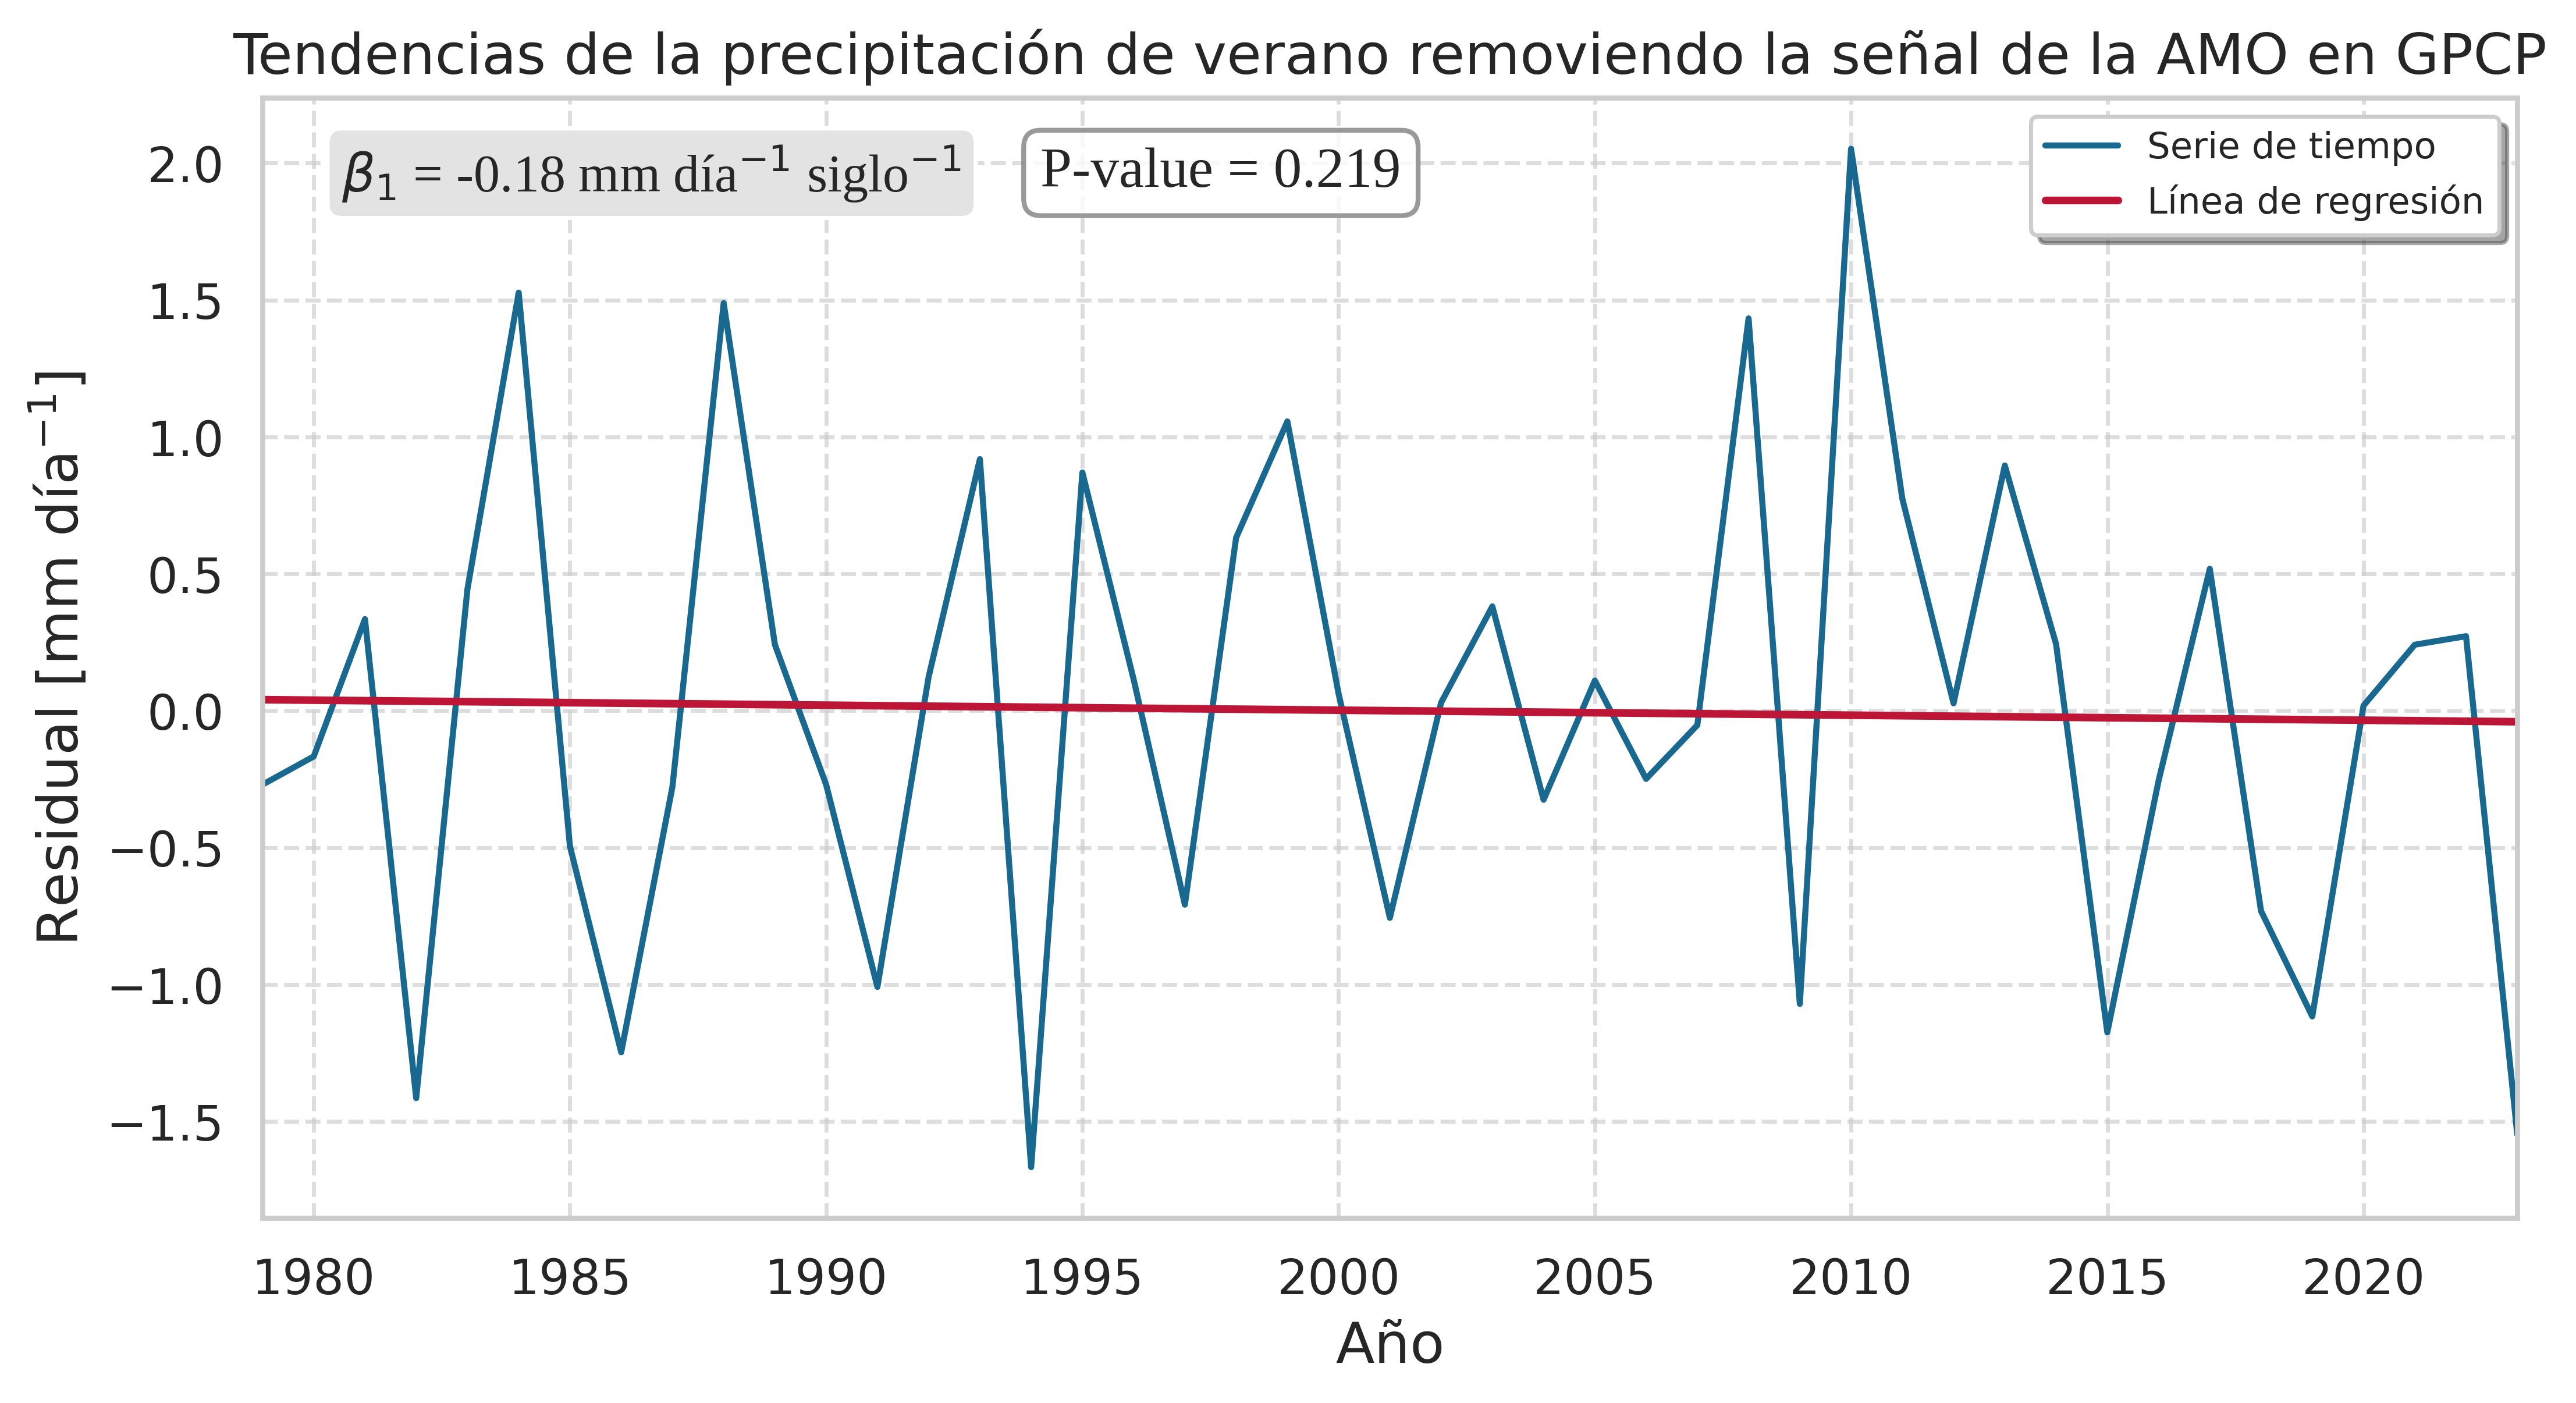

In [34]:
from matplotlib.lines import Line2D

# Graficamos los datos y la línea de regresión
plt.figure(figsize=(10,5), dpi=500)
plt.plot(years, residual, color='#186890', label='Serie de tiempo', linewidth=1.5)
plt.plot(years, predicciones, color='#bd1536', label='Línea de regresión', linewidth=1.9)
#plt.text(0.05, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=17, fontname='Liberation Serif', fontweight='bold', va='top', ha='right',
#        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27', linewidth=1))
lineplot_setup(1979,2023,'Año','Residual [mm día$^{-1}$]',title='Tendencias de la precipitación de verano removiendo la señal de la AMO en GPCP',legend=True)

plt.text(0.31, 0.96, r'$\beta_1$ = -0.18 mm día$^{-1}$ siglo$^{-1}$', transform=plt.gca().transAxes, fontsize=13, fontname='Liberation Serif', fontweight='normal', va='top', ha='right',
        bbox=dict(facecolor='#E3E3E3', edgecolor='white', boxstyle='round,pad=0.27', linewidth=1))

plt.text(0.505, 0.956,rf'P-value = 0.219',transform=plt.gca().transAxes,fontsize=14,fontname='Liberation Serif',fontweight='normal',va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='gray',boxstyle='round,pad=0.3',alpha=0.8,linewidth=1.2))

ax = plt.gca() 

In [35]:
pendiente, intercepto, r_value, pval, stderr = stats.linregress(years, residual)

print("magn. pendiente:", pendiente)
print("p-value:", pval)
if pval < 0.05:
    print("significativa al 95%")
else:
    print("no significativa al 95%")

magn. pendiente: -0.00183120101838557
p-value: 0.8545726912105878
no significativa al 95%


In [36]:
stats = stats.linregress(years, residual)
print(stats)

LinregressResult(slope=np.float64(-0.00183120101838557), intercept=np.float64(3.6642332377895253), rvalue=np.float64(-0.028108432564813348), pvalue=np.float64(0.8545726912105878), stderr=np.float64(0.009931012595232186), intercept_stderr=np.float64(19.87237474707546))
